# Lab 1. Базові алгоритми класифікації у Scikit-learn

## ФБ-61мп Тютюннікова Віолета

### Імпорт бібліотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn import set_config
set_config(display="text")
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
RANDOM_STATE = 42
PURPLE = "#8e7cc3"
LIGHT = "#c9bfe6"
soft = sns.light_palette(PURPLE, as_cmap=True)
soft_div = sns.blend_palette(["#9fd3c7", "#ffffff", PURPLE], as_cmap=True)
DARK_TEXT = {"color": "#2d2440"}

## 1. Завантаження та первинний аналіз даних

### Завантажуємо датасет

In [2]:
df = pd.read_parquet("cicdarknet2020.parquet")
df.head()

,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label.1
0,6,229,1,1,0,0,0,0,0.00000,0.000000,...,0,0,0,0,0.000000e+00,0.00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
1,6,407,1,1,0,0,0,0,0.00000,0.000000,...,0,0,0,0,0.000000e+00,0.00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
2,6,431,1,1,0,0,0,0,0.00000,0.000000,...,0,0,0,0,0.000000e+00,0.00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
3,6,359,1,1,0,0,0,0,0.00000,0.000000,...,0,0,0,0,0.000000e+00,0.00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
4,6,10778451,591,400,64530,6659,131,0,109.18782,22.283312,...,0,0,0,0,1.437760e+15,3117718.25,1.437760e+15,1.437760e+15,Non-Tor,AUDIO-STREAMING


### Виводимо назви колонок та розмір датасету

In [3]:
print("Розмір датасету:", df.shape)
print(list(df.columns))

Розмір датасету: (103121, 79)
['Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', '

### Визначаємо ознаки та цільову змінну

In [4]:
target = "Label"
print("Label:", df["Label"].unique())
print("Label.1:", df["Label.1"].unique())

Label: ['Non-Tor', 'NonVPN', 'Tor', 'VPN']
Categories (4, object): ['Non-Tor', 'NonVPN', 'Tor', 'VPN']
Label.1: ['AUDIO-STREAMING', 'Browsing', 'Chat', 'Email', 'File-Transfer', ..., 'P2P', 'Video-Streaming', 'Audio-Streaming', 'Video-streaming', 'VOIP']
Length: 11
Categories (11, object): ['AUDIO-STREAMING', 'Audio-Streaming', 'Browsing', 'Chat', ..., 'P2P', 'VOIP', 'Video-Streaming', 'Video-streaming']


Цільовою змінною буде стовпець Label, який має 4 класи: Non-Tor, NonVPN, Tor та VPN. Стовпець Label.1 показує тип активності, тобто це відповідь іншої задачі, тому як ознаку його не використовуємо і видалимо. Ознаками будуть решта 77 числових стовпців.

### Перевіряємо типи даних

In [5]:
print(df.dtypes.value_counts())
print()
print("Нечислові стовпці:", df.select_dtypes(exclude="number").columns.tolist())

int32       25
int8        22
float32     22
int16        6
float64      2
category     1
category     1
Name: count, dtype: int64

Нечислові стовпці: ['Label', 'Label.1']


Усі ознаки числові, нечисловими є лише мітки Label та Label.1.

### Перевіряємо розподіл об'єктів за класами

Label
Non-Tor    64804
NonVPN     20216
VPN        16922
Tor         1179
Name: count, dtype: int64


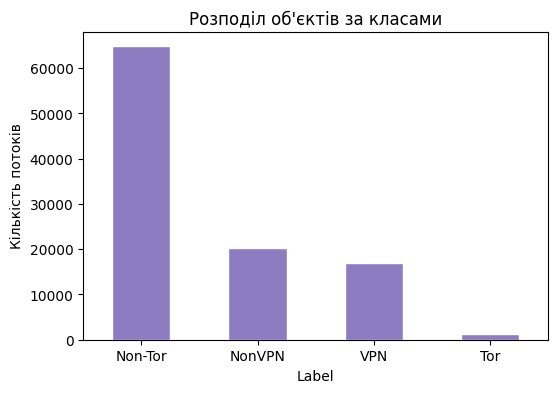

In [6]:
print(df[target].value_counts())

df[target].value_counts().plot(kind="bar", figsize=(6, 4), color=PURPLE, edgecolor="white")
plt.title("Розподіл об'єктів за класами")
plt.ylabel("Кількість потоків")
plt.xticks(rotation=0)
plt.show()

Класи незбалансовані - Non-Tor займає більшу частину даних, а Tor найменшу. Тому крім accuracy будемо дивитися на macro F1, де малий клас Tor має таку саму вагу, як і великі.

## 2. Попередня обробка даних

### Перевіряємо наявність пропущених значень

In [7]:
print("Пропусків усього:", df.isnull().sum().sum())
num = df.select_dtypes("number")
print("Нескінченних значень усього:", np.isinf(num).sum().sum())

Пропусків усього: 0
Нескінченних значень усього: 0


### Видаляємо мітку іншої задачі

In [8]:
df = df.drop(columns=["Label.1"])
print("Розмір:", df.shape)

Розмір: (103121, 78)


### Видаляємо дублікати та константні ознаки

In [9]:
print("Дублікатів:", df.duplicated().sum())
df = df.drop_duplicates()
print("Розмір після видалення дублікатів:", df.shape)

const_cols = [c for c in df.columns if c != target and df[c].nunique() <= 1]
print("Константні ознаки:", const_cols)
df = df.drop(columns=const_cols)
print("Розмір:", df.shape)

Дублікатів: 2649
Розмір після видалення дублікатів: (100472, 78)
Константні ознаки: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg', 'Bwd Bytes/Bulk Avg', 'Subflow Bwd Packets', 'Active Mean', 'Active Std', 'Active Max', 'Active Min']
Розмір: (100472, 63)


Після видалення Label.1 з'явилось 2 649 однакових рядків. Їх видаляємо, щоб однакові потоки не потрапили одночасно в train і test, інакше оцінка була б завищеною. Також видаляємо 15 ознак, які мають одне значення для всіх рядків і нічого не дають моделі.

### Кодуємо категоріальні ознаки

In [10]:
print(df["Protocol"].value_counts())

ohe = OneHotEncoder(sparse_output=False)
protocol_encoded = ohe.fit_transform(df[["Protocol"]])
protocol_df = pd.DataFrame(protocol_encoded,
                           columns=ohe.get_feature_names_out(["Protocol"]),
                           index=df.index)
df = pd.concat([df.drop(columns=["Protocol"]), protocol_df], axis=1)
protocol_df.head()

Protocol
6     59643
17    40060
0       769
Name: count, dtype: int64


,Protocol_0,Protocol_6,Protocol_17
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0


### Зменшуємо обсяг даних

In [11]:
df_s, _ = train_test_split(df, train_size=30000, stratify=df[target], random_state=RANDOM_STATE)
print(df_s.shape)
print(df_s[target].value_counts(normalize=True).round(3))

(30000, 65)
Label
Non-Tor    0.640
NonVPN     0.180
VPN        0.168
Tor        0.012
Name: proportion, dtype: float64


Після очищення залишилось близько 100 тис. потоків, тому беремо вибірку з 30 000 потоків зі збереженням пропорцій класів.

## 3. Візуалізація та дослідження даних (EDA)

### Відбираємо найінформативніші ознаки

In [12]:
X_eda = df_s.drop(columns=target)
mi = mutual_info_classif(X_eda, df_s[target], random_state=RANDOM_STATE)
mi = pd.Series(mi, index=X_eda.columns).sort_values(ascending=False)
top10 = mi.head(10).index.tolist()
print(mi.head(10))

corr = df_s[top10].corr().abs()
top6 = []
for col in top10:
    if all(corr.loc[col, other] < 0.8 for other in top6):
        top6.append(col)
top6 = top6[:6]
print("\nОзнаки:", top6)

Packet Length Max             0.457753
Packet Length Mean            0.439398
Idle Max                      0.433575
Avg Packet Size               0.426733
Idle Mean                     0.417602
Idle Min                      0.394727
FWD Init Win Bytes            0.385626
Total Length of Fwd Packet    0.361988
Flow IAT Max                  0.351699
Flow Duration                 0.349905
dtype: float64

Ознаки: ['Packet Length Max', 'Packet Length Mean', 'Idle Max', 'FWD Init Win Bytes', 'Total Length of Fwd Packet', 'Flow IAT Max']


Ознак понад 60, тому для графіків відбираємо 10 найінформативніших.

### Будуємо heatmap кореляцій

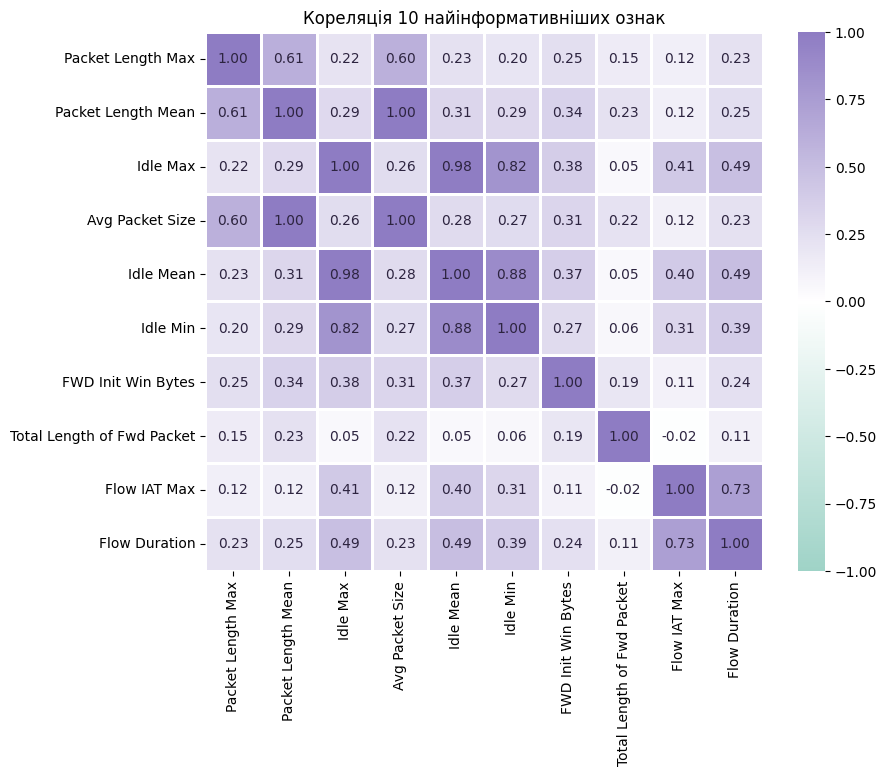

In [13]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_s[top10].corr(), annot=True, fmt=".2f", cmap=soft_div, vmin=-1, vmax=1,
            linewidths=1, linecolor="white", annot_kws=DARK_TEXT)
plt.title("Кореляція 10 найінформативніших ознак")
plt.show()

Деякі ознаки майже повторюють одна одну - Packet Length Mean та Avg Packet Size (1.00), Idle Max та Idle Mean (0.98). 

### Будуємо гістограми розподілу ознак

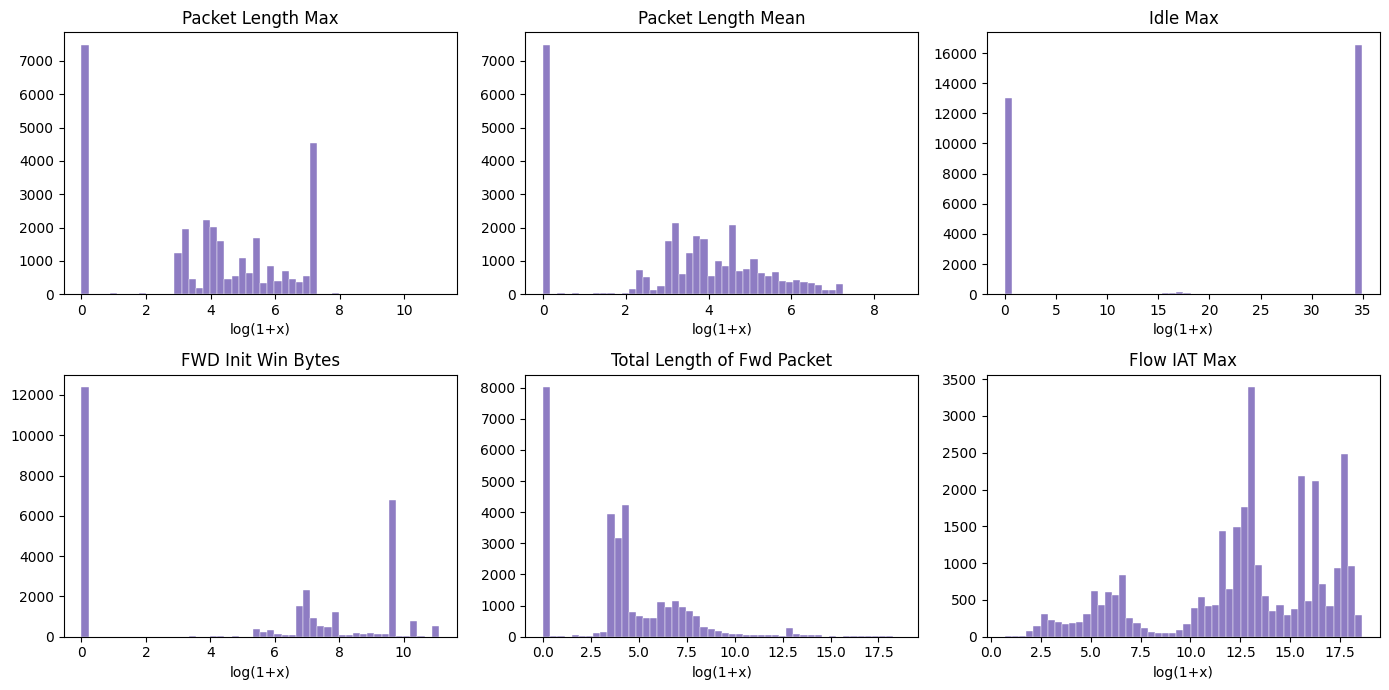

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, top6):
    ax.hist(np.log1p(df_s[col]), bins=50, color=PURPLE, edgecolor="white", linewidth=0.3)
    ax.set_title(col)
    ax.set_xlabel("log(1+x)")
plt.tight_layout()
plt.show()

Значення мають дуже великий розкид, тому використано шкалу log(1+x).

### Будуємо boxplot ознак відносно цільової змінної

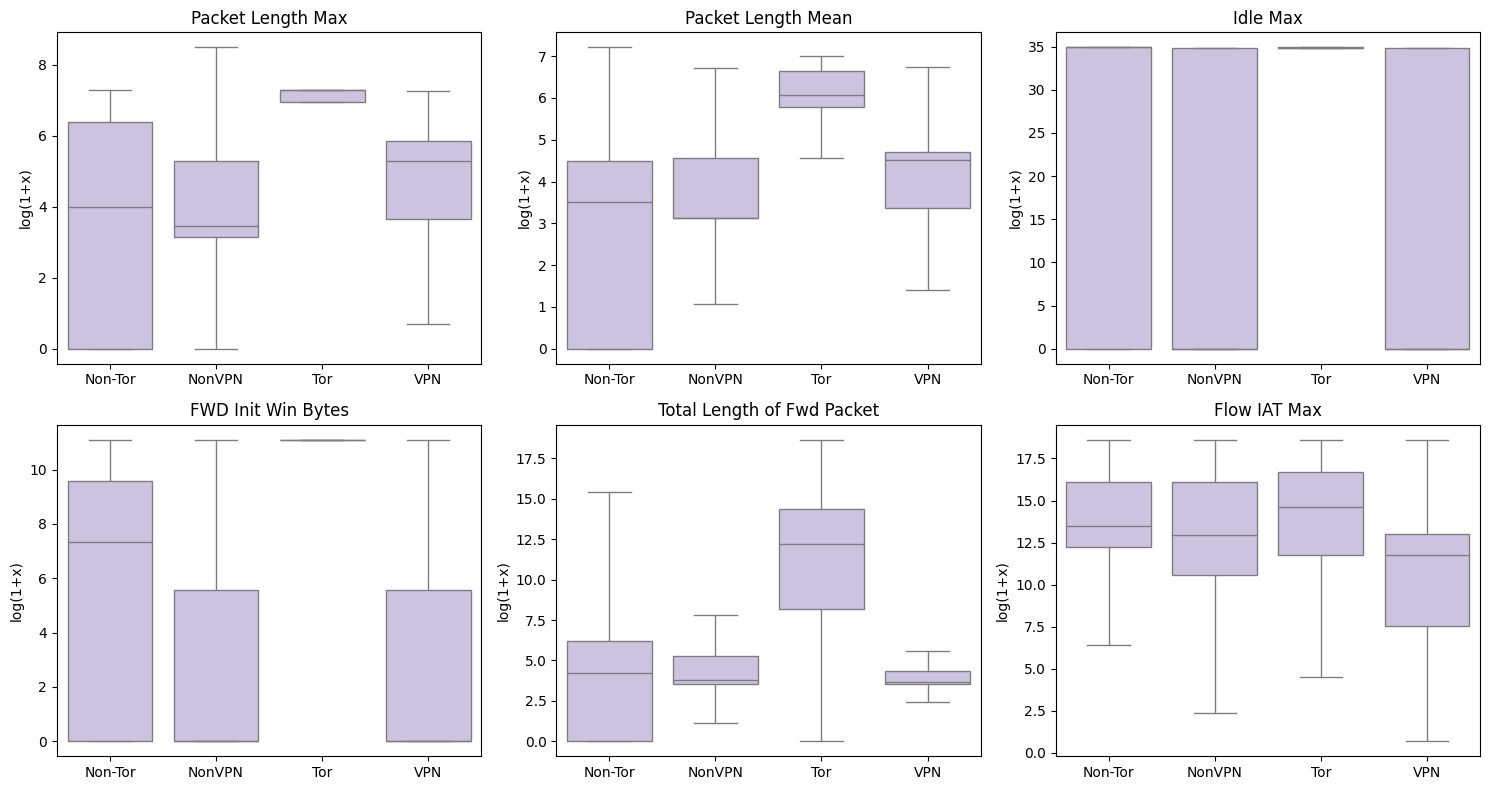

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, top6):
    sns.boxplot(x=df_s[target], y=np.log1p(df_s[col]), ax=ax, showfliers=False, color=LIGHT)
    ax.set_title(col)
    ax.set_ylabel("log(1+x)")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

Tor добре відрізняється від інших класів, бо у нього великі пакети, великий обсяг даних і майже завжди однакове FWD Init Win Bytes. А от VPN і NonVPN за цими ознаками дуже схожі, тому саме між ними очікуємо найбільше помилок.

## 4. Підготовка даних до навчання

### Розділяємо дані на training та test вибірки

In [16]:
X = df_s.drop(columns=target)
y = df_s[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (24000, 64) | Test: (6000, 64)


### Масштабуємо ознаки

In [17]:
scaler = StandardScaler()
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

StandardScaler приводить усі ознаки до одного масштабу, а навчаємо його тільки на train. Для дерев масштабування не потрібне, бо вони лише порівнюють ознаку з порогом.

## 5. Навчання моделей

### Функція для навчання моделі

In [18]:
results = {}  
preds = {}   

def train(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    preds[name] = pred
    results[name] = {"Accuracy": accuracy_score(y_test, pred),
                     "Macro F1": f1_score(y_test, pred, average="macro")}
    print(f"{name}: accuracy = {results[name]['Accuracy']:.4f}, macro F1 = {results[name]['Macro F1']:.4f}")

### Навчаємо k-Nearest Neighbors

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
pred_knn = train("kNN (k=5)", knn, scaled_X_train, scaled_X_test)

kNN (k=5): accuracy = 0.9347, macro F1 = 0.8716


### Навчаємо Decision Tree

In [20]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
pred_dt = train("Decision Tree", dt, X_train, X_test)

Decision Tree: accuracy = 0.9662, macro F1 = 0.9245


### Навчаємо Support Vector Machine

In [21]:
svm = SVC(kernel="rbf")
pred_svm = train("SVM (default)", svm, scaled_X_train, scaled_X_test)

SVM (default): accuracy = 0.8923, macro F1 = 0.8131


### Навчаємо Random Forest

In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
pred_rf = train("Random Forest", rf, X_train, X_test)

Random Forest: accuracy = 0.9720, macro F1 = 0.9377


### Навчаємо AdaBoost

In [23]:
ada = AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)
pred_ada = train("AdaBoost", ada, X_train, X_test)

AdaBoost: accuracy = 0.8758, macro F1 = 0.6012


## 6. Підбір гіперпараметрів

### Підбираємо n_neighbors для kNN

{'n_neighbors': 3}


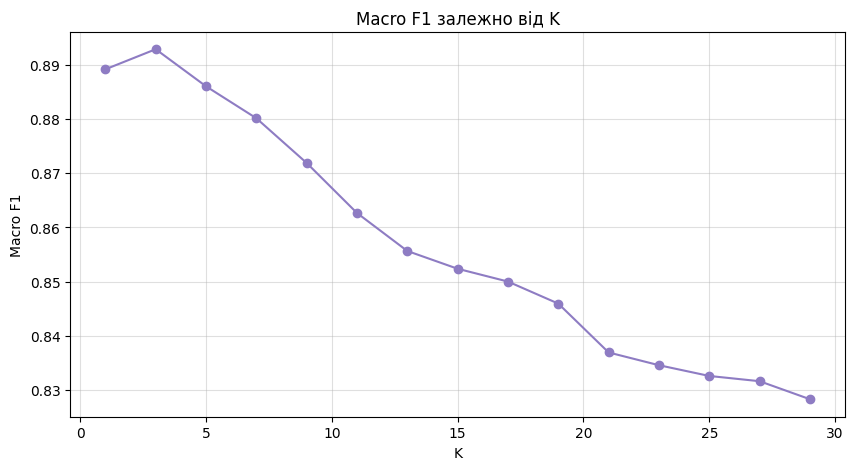

In [24]:
knn_grid = GridSearchCV(KNeighborsClassifier(), {"n_neighbors": range(1, 30, 2)},
                        cv=5, scoring="f1_macro", n_jobs=-1)
knn_grid.fit(scaled_X_train, y_train)
print(knn_grid.best_params_)

plt.figure(figsize=(10, 5))
plt.plot(list(range(1, 30, 2)), knn_grid.cv_results_["mean_test_score"], marker="o", color=PURPLE)
plt.title("Macro F1 залежно від K")
plt.xlabel("K"); plt.ylabel("Macro F1")
plt.grid(alpha=0.4)
plt.show()

Найкраще k = 3. При k = 1 модель залежить від одного сусіда і запам'ятовує шум, а при великих k якість падає, бо далекі сусіди часто з іншого класу.

In [25]:
best_k = knn_grid.best_params_["n_neighbors"]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
pred_knn_best = train(f"kNN (k={best_k})", knn_best, scaled_X_train, scaled_X_test)

kNN (k=3): accuracy = 0.9402, macro F1 = 0.8824


### Підбираємо C та gamma для SVM за допомогою GridSearchCV

{'C': 1000, 'gamma': 0.01, 'kernel': 'rbf'}


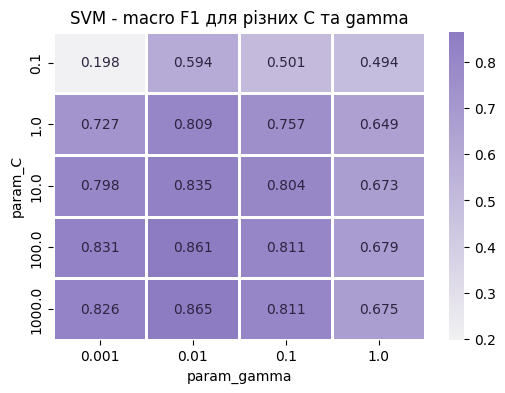

In [26]:
X_grid, _, y_grid, _ = train_test_split(scaled_X_train, y_train, train_size=5000,
                                        stratify=y_train, random_state=RANDOM_STATE)

param_grid = {"C": [0.1, 1, 10, 100, 1000], "gamma": [1, 0.1, 0.01, 0.001], "kernel": ["rbf"]}
grid = GridSearchCV(SVC(), param_grid, cv=3, scoring="f1_macro", n_jobs=-1)
grid.fit(X_grid, y_grid)
print(grid.best_params_)

heat = pd.DataFrame(grid.cv_results_).pivot(index="param_C", columns="param_gamma", values="mean_test_score")
plt.figure(figsize=(6, 4))
sns.heatmap(heat, annot=True, fmt=".3f", cmap=soft, linewidths=1, linecolor="white", annot_kws=DARK_TEXT)
plt.title("SVM - macro F1 для різних C та gamma")
plt.show()

Підбір робимо на 5000 об'єктах, бо інакше він дуже довгий. Найкраще C = 1000, gamma = 0.01.

In [27]:
svm_best = SVC(**grid.best_params_)
pred_svm_best = train("SVM", svm_best, scaled_X_train, scaled_X_test)

SVM: accuracy = 0.9365, macro F1 = 0.8708


### Досліджуємо глибину базових дерев для AdaBoost

In [28]:
for depth in [1, 2, 3]:
    m = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=depth),
                           n_estimators=100, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    print(f"max_depth={depth}: macro F1 = {f1_score(y_test, m.predict(X_test), average='macro'):.4f}")

max_depth=1: macro F1 = 0.6012
max_depth=2: macro F1 = 0.8639
max_depth=3: macro F1 = 0.9083


За замовчуванням AdaBoost використовує дерева глибини 1, які ставлять лише одне питання, і для 4 класів цього замало. А ось з глибиною 3 macro F1 зростає з 0.60 до 0.91.

In [29]:
ada_best = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                              n_estimators=100, random_state=RANDOM_STATE)
pred_ada_best = train("AdaBoost (depth=3)", ada_best, X_train, X_test)

AdaBoost (depth=3): accuracy = 0.9472, macro F1 = 0.9083


## 7. Порівняння та оцінювання моделей

### Порівнюємо результати всіх моделей

                    Accuracy  Macro F1
Random Forest         0.9720    0.9377
Decision Tree         0.9662    0.9245
AdaBoost (depth=3)    0.9472    0.9083
kNN (k=3)             0.9402    0.8824
kNN (k=5)             0.9347    0.8716
SVM                   0.9365    0.8708
SVM (default)         0.8923    0.8131
AdaBoost              0.8758    0.6012


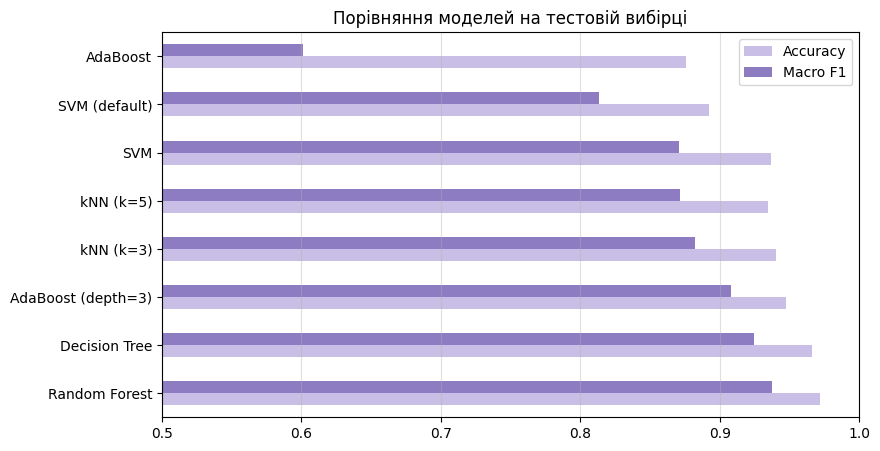

In [30]:
res = pd.DataFrame(results).T.sort_values("Macro F1", ascending=False)
print(res.round(4))

res.plot(kind="barh", figsize=(9, 5), xlim=(0.5, 1.0), color=[LIGHT, PURPLE])
plt.title("Порівняння моделей на тестовій вибірці")
plt.grid(axis="x", alpha=0.4)
plt.show()

Найкраще працює Random Forest, далі Decision Tree і AdaBoost з глибиною 3. kNN і SVM після підбору мають macro F1 близько 0.87-0.88, а найгірший - AdaBoost за замовчуванням.

### Виводимо classification_report та confusion_matrix

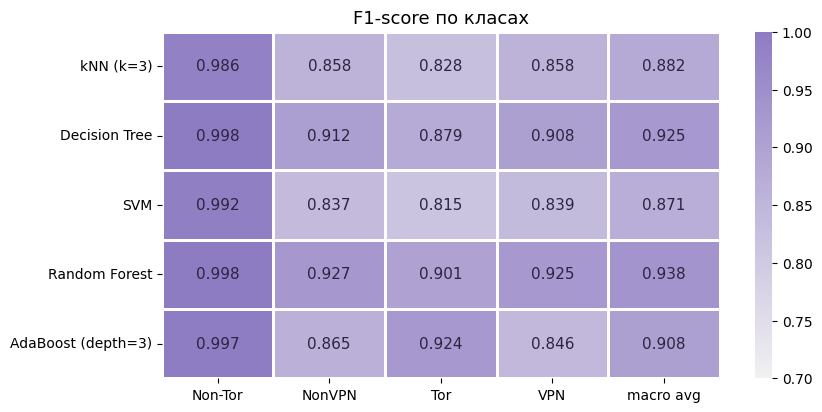

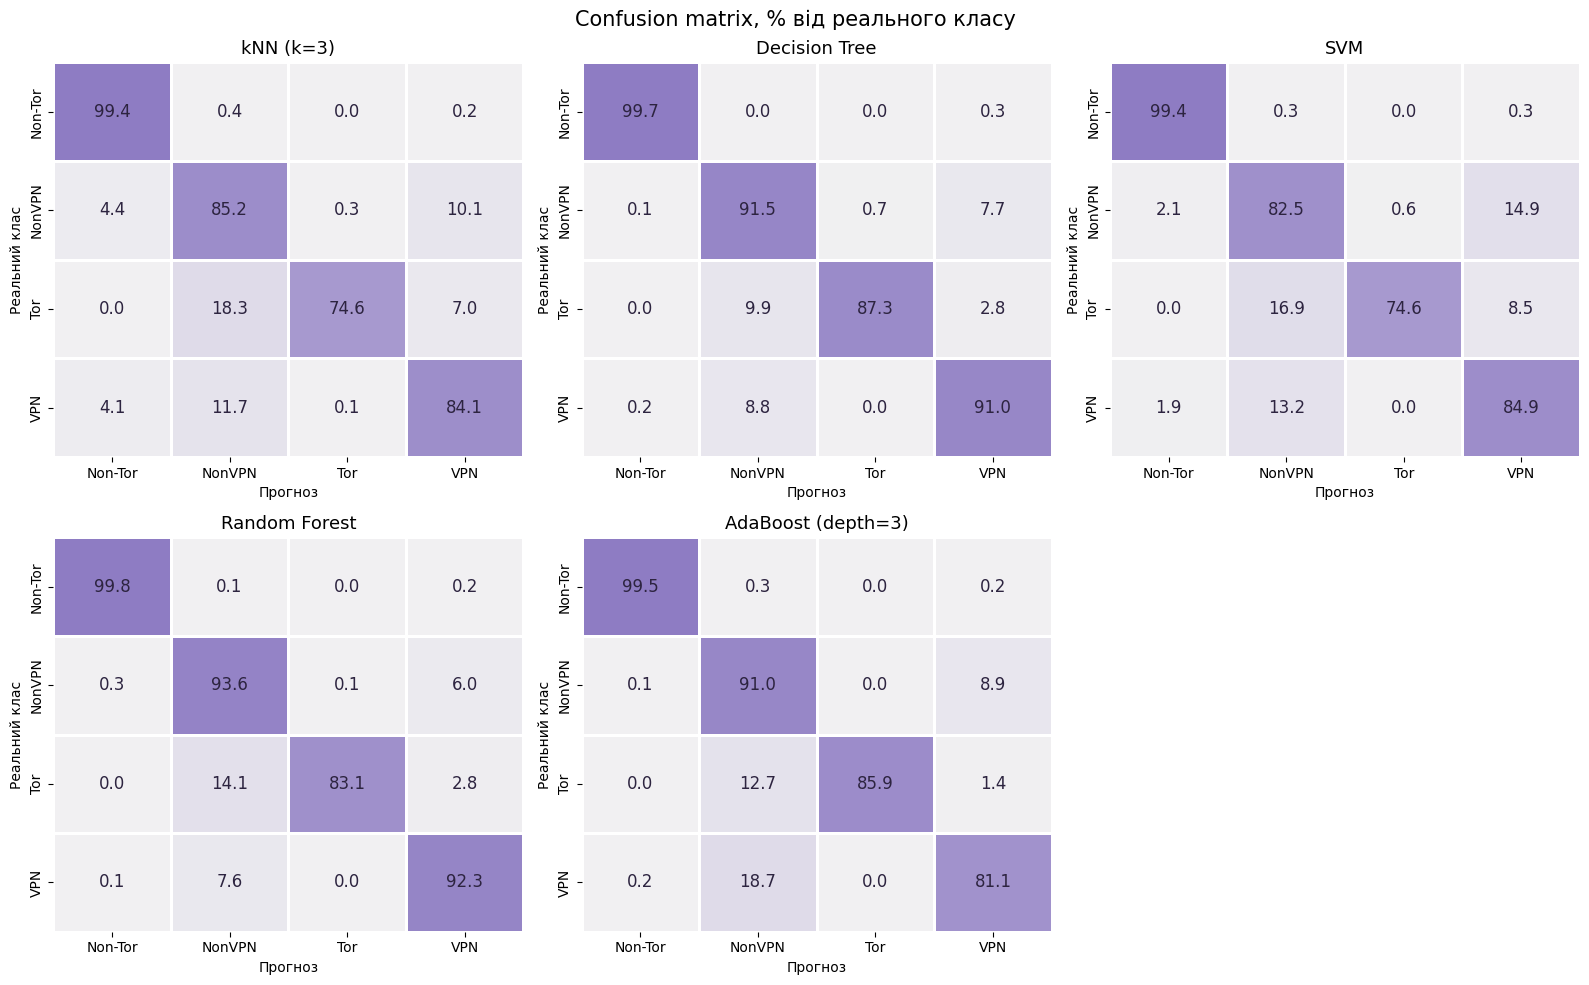

In [31]:
final = ["kNN (k=3)", "Decision Tree", "SVM", "Random Forest", "AdaBoost (depth=3)"]
labels = sorted(y.unique())

reports = {name: classification_report(y_test, preds[name], output_dict=True) for name in final}
f1_table = pd.DataFrame({name: {c: reports[name][c]["f1-score"] for c in labels + ["macro avg"]}
                         for name in final}).T

plt.figure(figsize=(9, 4.5))
sns.heatmap(f1_table, annot=True, fmt=".3f", cmap=soft, vmin=0.7, vmax=1,
            linewidths=2, linecolor="white", annot_kws={"color": "#2d2440", "fontsize": 11})
plt.title("F1-score по класах", fontsize=13)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, name in zip(axes.flat, final):
    cm = confusion_matrix(y_test, preds[name], labels=labels, normalize="true") * 100
    sns.heatmap(cm, annot=True, fmt=".1f", cmap=soft, vmin=0, vmax=100, cbar=False,
                linewidths=2, linecolor="white", annot_kws={"color": "#2d2440", "fontsize": 12},
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Прогноз"); ax.set_ylabel("Реальний клас")
axes.flat[-1].axis("off")
fig.suptitle("Confusion matrix, % від реального класу", fontsize=15)
plt.tight_layout()
plt.show()

Non-Tor усі моделі розпізнають майже без помилок. Найбільше помилок між NonVPN і VPN, як і очікували з boxplot-ів - Random Forest плутає їх приблизно у 6-8 % випадків, а SVM у 13-15 %. Tor kNN і SVM знаходять лише на 75 %, а моделі на основі дерев на 83-87 %.

## Висновок

Найкращий результат показав Random Forest - accuracy = 0.97, macro F1 = 0.94. Він найкраще розрізняє VPN і NonVPN та добре знаходить малий клас Tor.

Random Forest підходить для цих даних, бо дерева не залежать від масштабу ознак, легко знаходять нелінійні правила, їм не заважають схожі ознаки, а ансамбль із 100 дерев стабільніший за одне дерево (0.94 проти 0.92).

kNN і SVM працюють гірше (macro F1 близько 0.87-0.88), бо спираються на відстані, а тут багато ознак з великим розкидом і дублюючих ознак. Основні помилки всіх моделей - плутанина між VPN і NonVPN, що видно ще на EDA.